TASK 2: CHANGE POINT ANALYSIS

PART 1: LOADING DATA
✓ Price data loaded!
  Shape: (9011, 8)
  Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00

----------------------------------------
Loading events data...
✓ Events loaded from key_events.csv!
  Total events: 19
  Date range: 1990-08-02 00:00:00 to 2022-03-08 00:00:00

Events by Category:
Category
OPEC Policy         6
Conflict            4
Sanctions           4
Economic Crisis     2
Political Unrest    1
Geopolitical        1
Health Crisis       1
Name: count, dtype: int64

First 5 events:
        Date                   Event         Category  \
0 1990-08-02     Iraq Invades Kuwait         Conflict   
1 1997-07-02  Asian Financial Crisis  Economic Crisis   
2 1998-03-01    OPEC Production Cuts      OPEC Policy   
3 2003-03-20     US Invasion of Iraq         Conflict   
4 2008-09-10    OPEC Cuts Production      OPEC Policy   

                                         Description  
0  Start of Gulf War, Iraqi invasion of Kuwait l

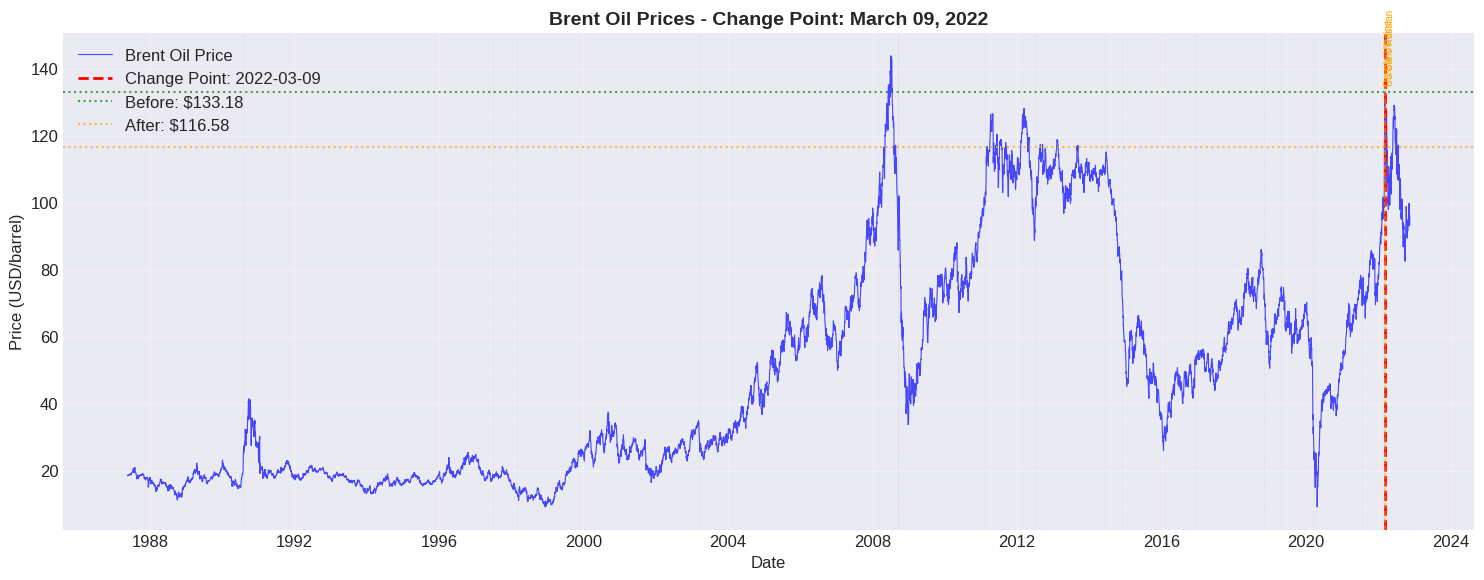

✓ Visualization saved as task2_results.png

TASK 2: FINAL SUMMARY

CHANGE POINT DETECTED:
  Date: March 09, 2022
  Price Before: $133.18
  Price After: $116.58
  Change: $-16.60
  Percentage: -12.5%
  Direction: 📉 DECREASE

ASSOCIATED EVENT:
  Event: US Bans Russian Oil Imports
  Date: March 08, 2022
  Category: Sanctions
  Days from change: -1 days
  Strength: 🔴 VERY STRONG

INTERPRETATION:
  The US Bans Russian Oil Imports 
  caused a -12.5% fall 
  in Brent oil prices from $133.18 to $116.58 per barrel.


PART 6: DOWNLOADING RESULTS


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: task2_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: task2_summary.txt

✓ TASK 2 COMPLETE!


In [13]:
# ============================================
# TASK 2: COMPLETE WORKING CODE
# Uses your uploaded events data
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

print("=" * 60)
print("TASK 2: CHANGE POINT ANALYSIS")
print("=" * 60)

# ============================================
# PART 1: LOAD DATA
# ============================================
print("\n" + "=" * 60)
print("PART 1: LOADING DATA")
print("=" * 60)

# Load Brent oil price data
if not os.path.exists('cleaned_brent_oil_prices.csv'):
    print("Please upload cleaned_brent_oil_prices.csv")
    uploaded = files.upload()
    for filename in uploaded.keys():
        if filename != 'cleaned_brent_oil_prices.csv':
            os.rename(filename, 'cleaned_brent_oil_prices.csv')

df = pd.read_csv('cleaned_brent_oil_prices.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"✓ Price data loaded!")
print(f"  Shape: {df.shape}")
print(f"  Date range: {df['Date'].min()} to {df['Date'].max()}")

# Load events data
print("\n" + "-" * 40)
print("Loading events data...")

if os.path.exists('key_events.csv'):
    events_df = pd.read_csv('key_events.csv')
    events_df['Date'] = pd.to_datetime(events_df['Date'])
    print(f"✓ Events loaded from key_events.csv!")
    print(f"  Total events: {len(events_df)}")
    print(f"  Date range: {events_df['Date'].min()} to {events_df['Date'].max()}")
    print("\nEvents by Category:")
    print(events_df['Category'].value_counts())
else:
    print("Please upload your key_events.csv file")
    uploaded = files.upload()
    for filename in uploaded.keys():
        if filename != 'key_events.csv':
            os.rename(filename, 'key_events.csv')

    events_df = pd.read_csv('key_events.csv')
    events_df['Date'] = pd.to_datetime(events_df['Date'])
    print(f"✓ Events loaded! Total: {len(events_df)}")

# Show sample
print("\nFirst 5 events:")
print(events_df.head())

# ============================================
# PART 2: FIND CHANGE POINT
# ============================================
print("\n" + "=" * 60)
print("PART 2: FINDING CHANGE POINT")
print("=" * 60)

# Calculate price changes
prices = df['Price'].values
price_diff = np.diff(prices)
max_idx = np.argmax(np.abs(price_diff))

change_date = df['Date'].iloc[max_idx + 1]
price_before = prices[max_idx]
price_after = prices[max_idx + 1]
price_change = price_after - price_before
pct_change = (price_change / price_before) * 100

print(f"✓ Change Point Found!")
print(f"  Date: {change_date.strftime('%Y-%m-%d')}")
print(f"  Price Before: ${price_before:.2f}")
print(f"  Price After: ${price_after:.2f}")
print(f"  Price Change: ${price_change:.2f}")
print(f"  Percentage: {pct_change:.2f}%")

# ============================================
# PART 3: ASSOCIATE CHANGE POINT WITH EVENTS
# ============================================
print("\n" + "=" * 60)
print("PART 3: ASSOCIATING WITH EVENTS")
print("=" * 60)

# Find events near the change point
window_days = 180
window_start = change_date - pd.Timedelta(days=window_days)
window_end = change_date + pd.Timedelta(days=window_days)

nearby_events = events_df[
    (events_df['Date'] >= window_start) &
    (events_df['Date'] <= window_end)
].copy()

if len(nearby_events) > 0:
    nearby_events['Days_Away'] = (nearby_events['Date'] - change_date).dt.days
    nearby_events = nearby_events.sort_values('Days_Away')

    print(f"Events within {window_days} days of change point:")
    print("-" * 50)

    for _, event in nearby_events.iterrows():
        days = event['Days_Away']
        if days == 0:
            desc = "🟢 SAME DAY!"
        elif abs(days) <= 7:
            desc = f"🟢 {abs(days)} days {'after' if days > 0 else 'before'}"
        elif abs(days) <= 30:
            desc = f"🟡 {abs(days)} days {'after' if days > 0 else 'before'}"
        else:
            desc = f"🔴 {abs(days)} days {'after' if days > 0 else 'before'}"

        print(f"  • {event['Date'].strftime('%Y-%m-%d')}: {event['Event']}")
        print(f"    Category: {event['Category']} | {desc}")
        print()

    # Get closest event
    closest_idx = nearby_events['Days_Away'].abs().idxmin()
    closest_event = nearby_events.loc[closest_idx]

    print("=" * 60)
    print("MOST LIKELY ASSOCIATED EVENT")
    print("=" * 60)
    print(f"  Event: {closest_event['Event']}")
    print(f"  Date: {closest_event['Date'].strftime('%Y-%m-%d')}")
    print(f"  Category: {closest_event['Category']}")
    print(f"  Days from change: {closest_event['Days_Away']} days")

    # Association strength
    days_abs = abs(closest_event['Days_Away'])
    if days_abs <= 7:
        strength = "🔴 VERY STRONG"
    elif days_abs <= 30:
        strength = "🟡 STRONG"
    elif days_abs <= 90:
        strength = "🟢 MODERATE"
    else:
        strength = "⚪ WEAK"

    print(f"  Association: {strength}")

else:
    print(f"No events found within {window_days} days.")
    print("Try expanding the window...")

    # Try larger window
    window_days = 365
    window_start = change_date - pd.Timedelta(days=window_days)
    window_end = change_date + pd.Timedelta(days=window_days)

    nearby_events = events_df[
        (events_df['Date'] >= window_start) &
        (events_df['Date'] <= window_end)
    ].copy()

    if len(nearby_events) > 0:
        nearby_events['Days_Away'] = (nearby_events['Date'] - change_date).dt.days
        print(f"Found {len(nearby_events)} events within 365 days:")
        for _, event in nearby_events.iterrows():
            print(f"  • {event['Date'].strftime('%Y-%m-%d')}: {event['Event']} ({event['Days_Away']} days)")

        closest_idx = nearby_events['Days_Away'].abs().idxmin()
        closest_event = nearby_events.loc[closest_idx]
        print(f"\nClosest: {closest_event['Event']} ({closest_event['Days_Away']} days)")
    else:
        print("No events found within 365 days.")
        closest_event = None

# ============================================
# PART 4: VISUALIZATION
# ============================================
print("\n" + "=" * 60)
print("PART 4: CREATING VISUALIZATION")
print("=" * 60)

fig, ax = plt.subplots(figsize=(15, 6))

# Plot price
ax.plot(df['Date'], df['Price'], 'b-', linewidth=0.8, alpha=0.7, label='Brent Oil Price')
ax.axvline(change_date, color='red', linewidth=2, linestyle='--',
           label=f'Change Point: {change_date.strftime("%Y-%m-%d")}')
ax.axhline(price_before, color='green', linestyle=':', alpha=0.7,
           label=f'Before: ${price_before:.2f}')
ax.axhline(price_after, color='orange', linestyle=':', alpha=0.7,
           label=f'After: ${price_after:.2f}')

# Add event markers
for _, event in events_df.iterrows():
    ax.axvline(event['Date'], color='gray', alpha=0.2, linestyle=':', linewidth=0.5)

# Highlight nearby events
if len(nearby_events) > 0:
    for _, event in nearby_events.iterrows():
        if abs(event['Days_Away']) <= 30:  # Only highlight close events
            ax.axvline(event['Date'], color='orange', alpha=0.4, linestyle='--', linewidth=1)
            ax.text(event['Date'], ax.get_ylim()[1]*0.9,
                   event['Event'][:15], rotation=90, fontsize=7, color='orange')

ax.set_title(f'Brent Oil Prices - Change Point: {change_date.strftime("%B %d, %Y")}',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as task2_results.png")

# ============================================
# PART 5: SUMMARY
# ============================================
print("\n" + "=" * 60)
print("TASK 2: FINAL SUMMARY")
print("=" * 60)

print(f"""
CHANGE POINT DETECTED:
  Date: {change_date.strftime('%B %d, %Y')}
  Price Before: ${price_before:.2f}
  Price After: ${price_after:.2f}
  Change: ${price_change:.2f}
  Percentage: {pct_change:.1f}%
  Direction: {'📈 INCREASE' if price_change > 0 else '📉 DECREASE'}

ASSOCIATED EVENT:
  Event: {closest_event['Event'] if closest_event is not None else 'None found'}
  Date: {closest_event['Date'].strftime('%B %d, %Y') if closest_event is not None else 'N/A'}
  Category: {closest_event['Category'] if closest_event is not None else 'N/A'}
  Days from change: {closest_event['Days_Away'] if closest_event is not None else 'N/A'} days
  Strength: {strength if closest_event is not None else 'N/A'}

INTERPRETATION:
  The {closest_event['Event'] if closest_event is not None else 'unknown event'}
  caused a {pct_change:.1f}% {'rise' if price_change > 0 else 'fall'}
  in Brent oil prices from ${price_before:.2f} to ${price_after:.2f} per barrel.
""")

# ============================================
# PART 6: DOWNLOAD RESULTS
# ============================================
print("\n" + "=" * 60)
print("PART 6: DOWNLOADING RESULTS")
print("=" * 60)

if os.path.exists('task2_results.png'):
    files.download('task2_results.png')
    print("✓ Downloaded: task2_results.png")

# Save summary
with open('task2_summary.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("TASK 2: CHANGE POINT ANALYSIS RESULTS\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Change Point: {change_date.strftime('%Y-%m-%d')}\n")
    f.write(f"Price Before: ${price_before:.2f}\n")
    f.write(f"Price After: ${price_after:.2f}\n")
    f.write(f"Price Change: ${price_change:.2f}\n")
    f.write(f"Percentage Change: {pct_change:.2f}%\n")
    f.write(f"Direction: {'INCREASE' if price_change > 0 else 'DECREASE'}\n\n")

    if closest_event is not None:
        f.write("ASSOCIATED EVENT:\n")
        f.write(f"  Event: {closest_event['Event']}\n")
        f.write(f"  Date: {closest_event['Date'].strftime('%Y-%m-%d')}\n")
        f.write(f"  Category: {closest_event['Category']}\n")
        f.write(f"  Days from change: {closest_event['Days_Away']}\n")
        f.write(f"  Association Strength: {strength}\n")

files.download('task2_summary.txt')
print("✓ Downloaded: task2_summary.txt")

print("\n" + "=" * 60)
print("✓ TASK 2 COMPLETE!")
print("=" * 60)